# Importing Dependencies

In [17]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

# Defining Variables

$T$: Time till maturity (expressed in years)

$n$: Number of time steps (e.g. $n$ = 252 days)

$\Delta t$: Time step size (calculated as $\Delta t = \frac{T}{n}$)

$\rho$: Correlation coefficient (correlation between shocks in volatility and shocks in price)

$\nu$: Volatility of volatility (Controls the variance of $\alpha$ process)

$F$: Asset's forward price

$\beta$: Elasticity parameter ($\beta=0$ gives normal (Bachelier style) SABR model and $\beta=1$ gives log-normal (Black style) SABR model)

$W_F$: Wiener process for forward prices

$\alpha$: Instantaneous volatility of forward price

$W_\alpha$: Wiener process for volatility process

In [18]:
T = 1
n = 252
dt = T/n
rho = -0.7
num_paths = 100
v = 0.04
F0 = 1
alpha0 = 0.2
beta = 1

Z_1 = np.random.normal(0,1,(n,num_paths))
Z_2 = np.random.normal(0,1,(n,num_paths))

W_F = Z_1
W_alpha = rho * Z_1 + np.sqrt(1-rho**2) * Z_2

alpha = np.insert(np.zeros((n,num_paths),dtype=float),0,alpha0,axis=0)
F = np.insert(np.zeros((n,num_paths),dtype=float),0,F0,axis=0)

# Simulating Paths

**Discrete Volatility Component:**

$$\alpha_{j,i+1} = \alpha_{j,i} \exp\left( -\frac{1}{2} \nu^2 \Delta t + \nu \sqrt{\Delta t} W_{\alpha, j,i} \right)$$

**Discrete Time Forward Process:**

$$F_{j,i+1} = \max\left( F_{j,i} + \alpha_{j,i} F_{j,i}^\beta \sqrt{\Delta t} W_{F, j,i}, 0 \right)$$

Where $i \in [0,n-1]$ and $j\in[1,\text{num_paths}]$

In [19]:
for i in range(0,n):
  alpha[i+1] = alpha[i] * np.exp(-0.5 * v**2 * dt + v * np.sqrt(dt) * W_alpha[i])
  F[i+1] = np.maximum(F[i] + alpha[i] * F[i] ** beta * np.sqrt(dt) * W_F[i],0)

# Plotting Paths

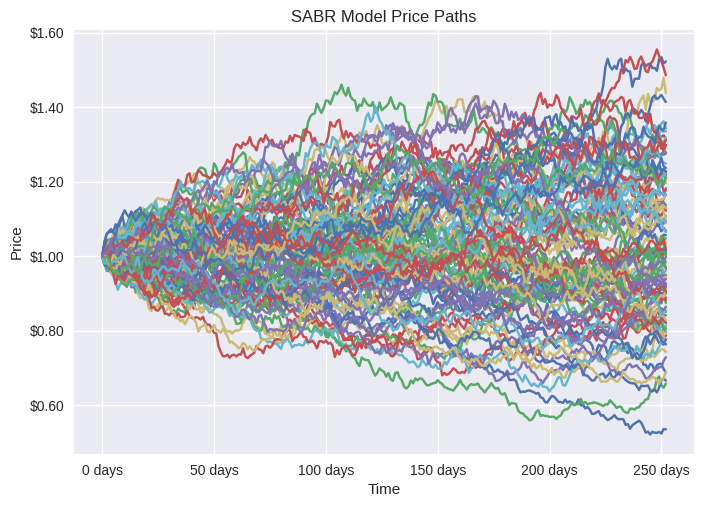

In [20]:
plt.plot(F)
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("SABR Model Price Paths")
plt.gca().yaxis.set_major_formatter("${x:,.2f}")
plt.gca().xaxis.set_major_formatter("{x:,.0f} days")
plt.show()